### Manuscript figures

In [59]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path
from collections import defaultdict

import torch
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, r2_score

from notebook_utils.embedding_helpers import load_encoded_latents, load_encoded_metadata
from notebook_utils.plotting_helpers import (
    load_point_regression_json,
    parity_cell_counts,
    plot_emergent_parity_row,
    plot_parity_size_legend,
    plot_trajectory_confusion_panels,
    print_emergent_parity_legend,
)

from simulation_encoder.loaders.loader_retrieval import load_loaders
from simulation_encoder.models.model_retrieval import load_models
from notebook_utils.image_dataset_index import (
    find_sample_indices_in_image_dataset,
    resolve_sample_index_in_loaders,
)

from notebook_utils.figure_helpers import (
    collect_spatial_mse_train_test,
    plot_figure2b_spatial_mse_bars,
    collect_timepoint_parity_data,
    plot_figure2c_timepoint_parity,
    plot_figure5b_saliency_row,
    show_figure5b_figures,
    rank_pcs_by_reconstruction_importance,
    generate_pc_perturbation_diffs,
    plot_figure5c_pc_diffs,
    show_figure5c_figures,
    compute_pc_perturbation_psd,
    plot_figure5c_psd_comparison,
    summarize_pc_perturbation_psd_table,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
STUDY = "gastruloid" # "gastruloid" | "arcade"

CFG = {
    "gastruloid": {
        "study_dir": "architecture-gastruloid",
        "num_timepoints": 9,
        "dataset_name": "gastruloid_128",
        "figures_subdir": "gastruloid",
    },
    "arcade": {
        "study_dir": "architecture-ARCADE",
        "num_timepoints": 15,
        "dataset_name": "vascular_function_128",
        "figures_subdir": "ARCADE",
    },
}

image_dir = "data"
c = CFG[STUDY]
results_dir = f"results/{c['study_dir']}"
num_timepoints = c["num_timepoints"]
dataset_name = c["dataset_name"]

raw = load_models(
    results_dir,
    num_timepoints=num_timepoints,
    best_models_flag=True,
    map_location="cpu",
)
all_models = {
    k: v
    for k, v in sorted(raw.items())
}
loaders = load_loaders(results_dir, image_dir)
data_loaders = {
    name: {
        "train": ldr.get_dataloader("train"),
        "val": ldr.get_dataloader("val"),
        "test": ldr.get_dataloader("test"),
        "full": ldr,
    }
    for name, ldr in sorted(loaders.items())
}

print(STUDY, results_dir, list(all_models.keys()))


arcade results/architecture-ARCADE ['ae', 'cae', 'neuralop', 'vit']


# Figure 2

In [61]:
rows = collect_spatial_mse_train_test(
    results_dir,
    all_models,
    data_loaders,
    device="cpu"
)
for r in rows:
    print(
        f"{r['model']:12}  train(min)={r['train_mse']:.6f}  test={r['test_mse']:.6f}"
    )


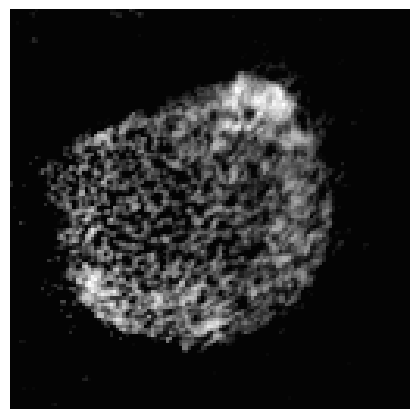

KeyError: 'gastruloid_128'

In [62]:
# Fig 2a
def tensor_to_imshow(x: torch.Tensor) -> np.ndarray:
    t = x.detach().float().cpu()
    if t.ndim == 4:
        t = t[0]
    t = torch.clamp(t, 0.0, 1.0)
    if t.shape[0] == 1:
        return t.squeeze(0).numpy()
    return t.permute(1, 2, 0).numpy()

if STUDY == "gastruloid":
    fig2a_sample_id = "array1_346"
    fig2a_timepoint = 1
else:
    fig2a_sample_id = "CH_Sav_8"
    fig2a_timepoint = 14

sample_idx, fig2a_split, dataset = resolve_sample_index_in_loaders(
    data_loaders[dataset_name],
    fig2a_sample_id,
    fig2a_timepoint,
)
img, tp = dataset[sample_idx]
x = img.unsqueeze(0)

model_names = sorted(all_models.keys())

im0 = tensor_to_imshow(img)
original_fig = plt.figure(figsize=(4.0, 4.0), frameon=False)
ax_o = original_fig.add_axes([0, 0, 1, 1])
if im0.ndim == 2:
    ax_o.imshow(im0, cmap="gray", vmin=0.0, vmax=1.0, interpolation="nearest")
else:
    ax_o.imshow(im0, interpolation="nearest")
ax_o.set_axis_off()
plt.show()

for name in model_names:
    model = all_models[name][dataset_name]
    model.eval()
    dev = next(model.parameters()).device
    with torch.no_grad():
        pred_img, pred_tp = model(x.to(dev))
    arr = tensor_to_imshow(pred_img)
    recon_fig = plt.figure(figsize=(4.0, 4.0), frameon=False)
    ax_r = recon_fig.add_axes([0, 0, 1, 1])
    if arr.ndim == 2:
        ax_r.imshow(arr, cmap="gray", vmin=0.0, vmax=1.0, interpolation="nearest")
    else:
        ax_r.imshow(arr, interpolation="nearest")
    ax_r.set_axis_off()
    plt.show()
plt.show()


Bar order (left → right): ae (vascular_function_128) | cae (vascular_function_128) | neuralop (vascular_function_128) | vit (vascular_function_128)


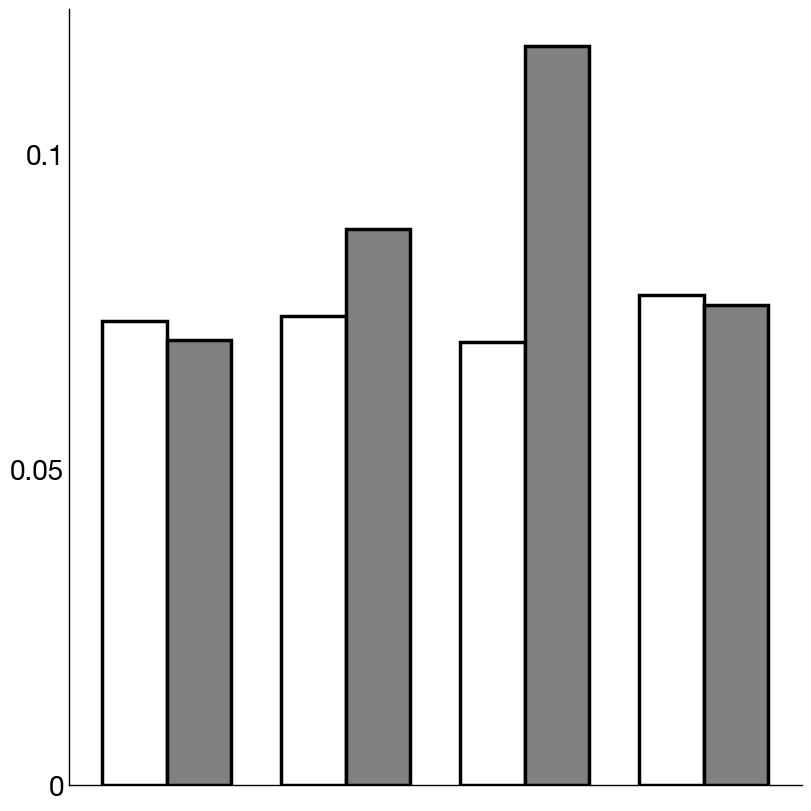

In [ ]:
if STUDY == "gastruloid":
    yticks = [0.0, 0.005, 0.01, 0.015]
    ytick_labels = ["0", "0.005", "0.01", "0.015"]
else:
    yticks = [0.0, 0.0005, 0.001]
    ytick_labels = ["0", "0.05", "0.1"]

fig = plot_figure2b_spatial_mse_bars(
    rows,
    yticks=yticks,
    ytick_labels=ytick_labels,
)

ae r2=0.912
cae r2=0.907
neuralop r2=0.732
vit r2=0.899


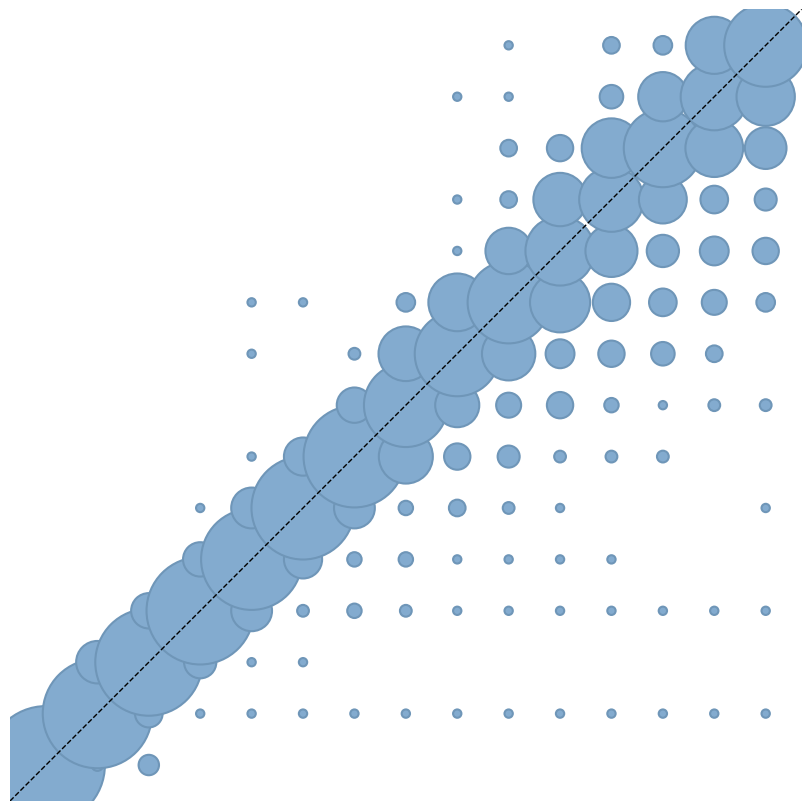

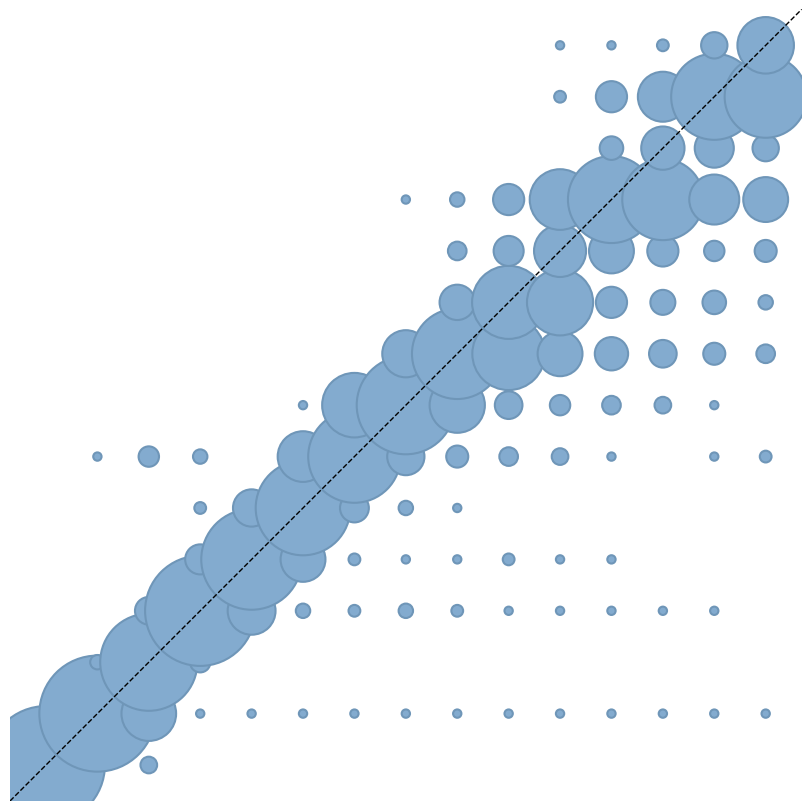

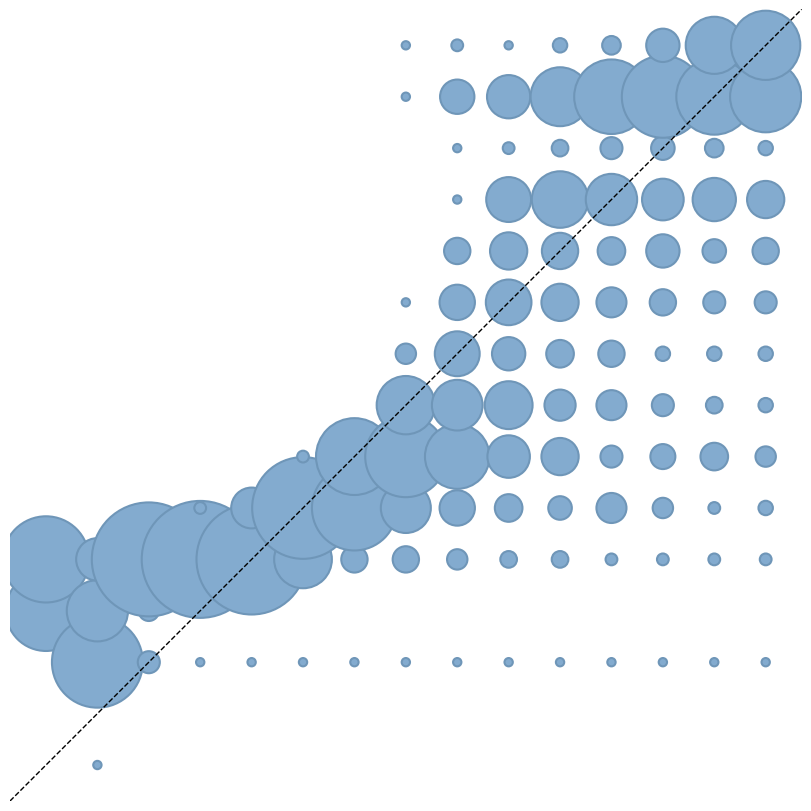

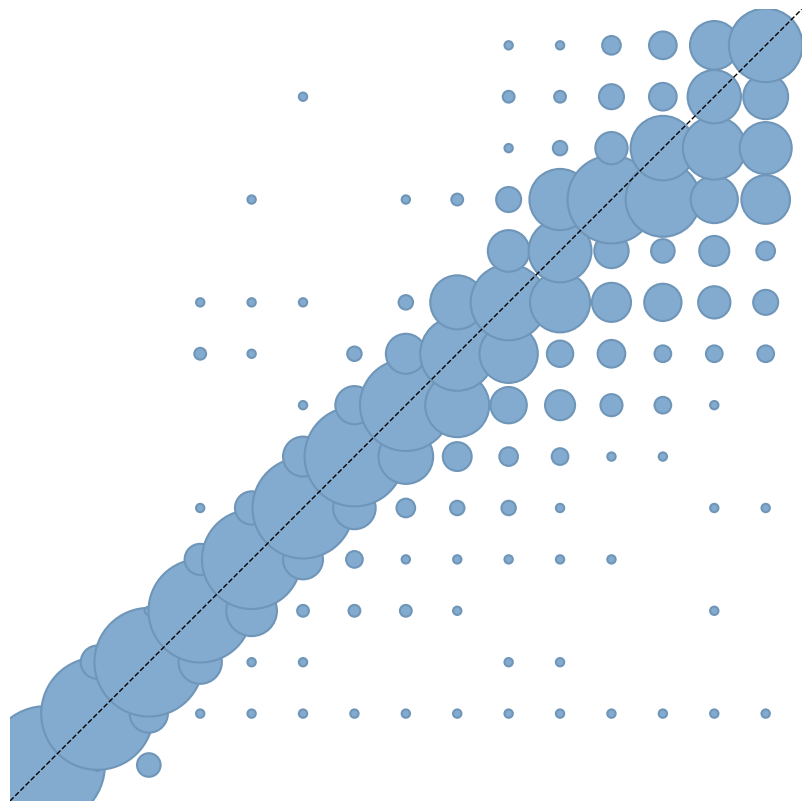

In [ ]:
parity = collect_timepoint_parity_data(
    results_dir,
    all_models,
    split="test",
    device="cpu",
)

for model_name in sorted(parity.keys()):
    for dataset_name in sorted(parity[model_name].keys()):
        block = parity[model_name][dataset_name]
        y_true = block["true"]
        y_pred = block["pred"]
        print(f"{model_name} r2={r2_score(y_true, y_pred):.3f}")

        fig, ax = plot_figure2c_timepoint_parity(
            y_true,
            y_pred,
        )


# Figure 3

  ae | vascular_function_128 | F1 C = 0.551    F1 CH = 0.518
  ae | vascular_function_128 | C → C | n=57
  ae | vascular_function_128 | C → CH | n=50
  ae | vascular_function_128 | CH → C | n=43
  ae | vascular_function_128 | CH → CH | n=50


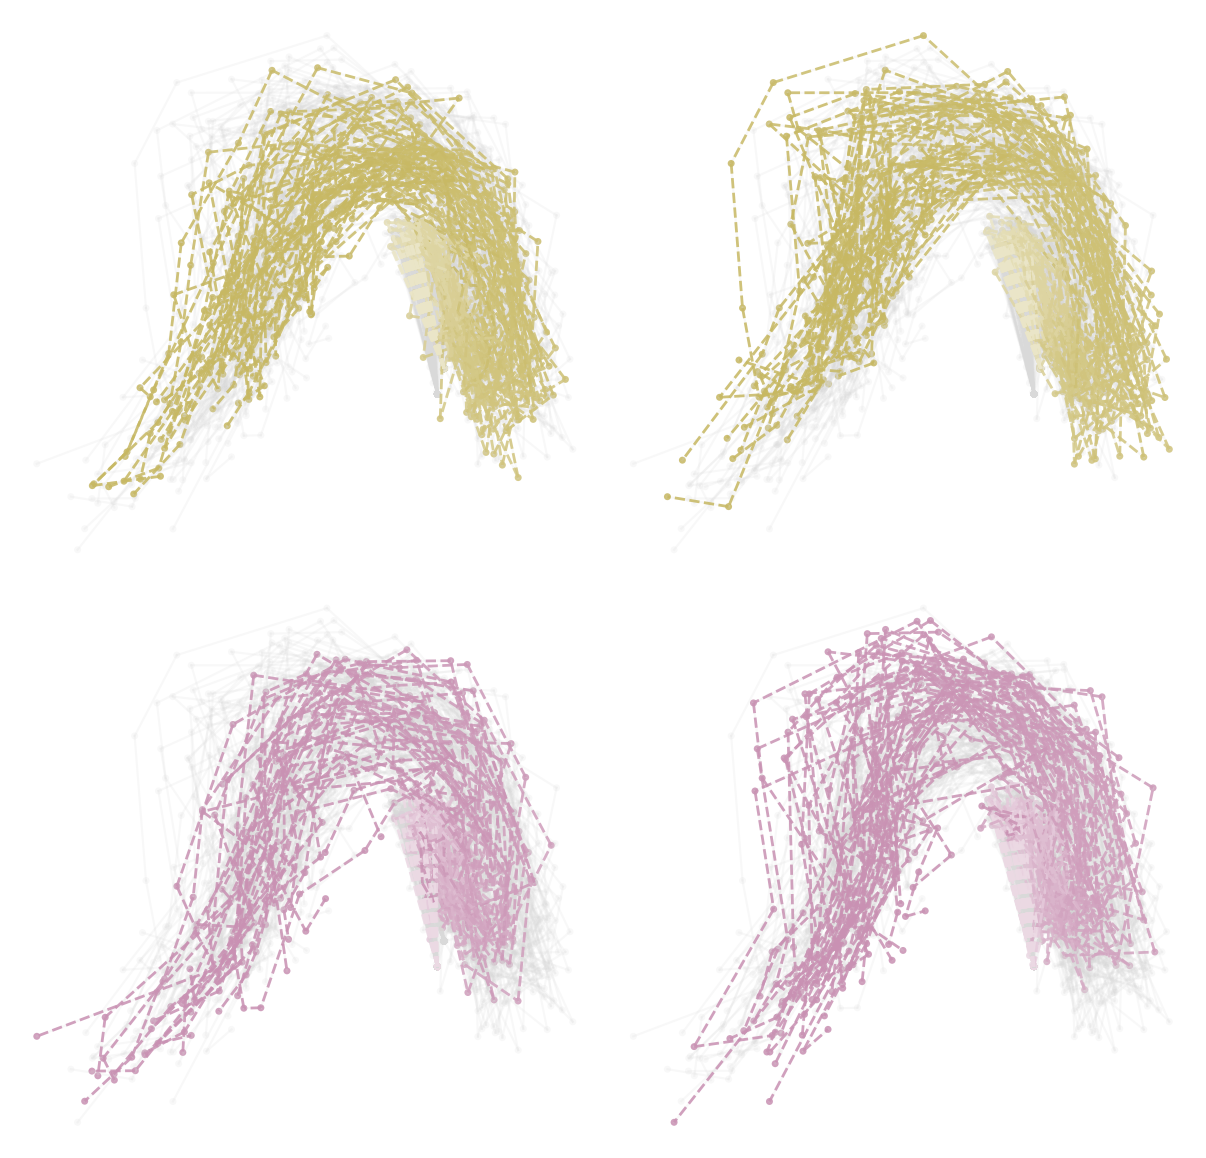

  cae | vascular_function_128 | F1 C = 0.676    F1 CH = 0.596
  cae | vascular_function_128 | C → C | n=75
  cae | vascular_function_128 | C → CH | n=32
  cae | vascular_function_128 | CH → C | n=40
  cae | vascular_function_128 | CH → CH | n=53


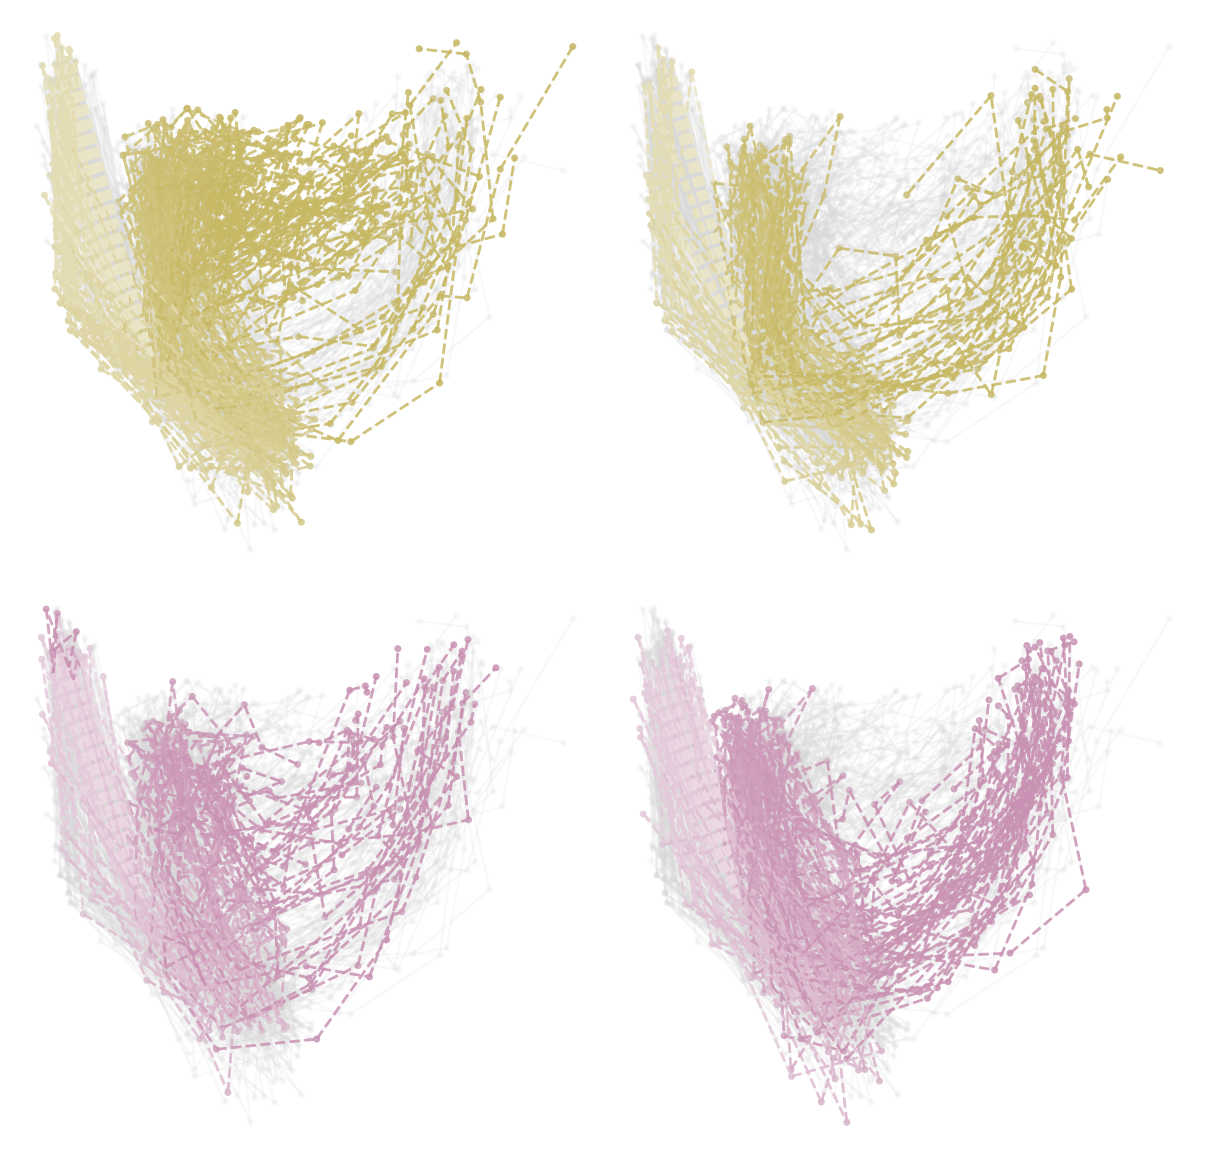

  neuralop | vascular_function_128 | F1 C = 0.799    F1 CH = 0.591
  neuralop | vascular_function_128 | C → C | n=107
  neuralop | vascular_function_128 | C → CH | n=0
  neuralop | vascular_function_128 | CH → C | n=54
  neuralop | vascular_function_128 | CH → CH | n=39


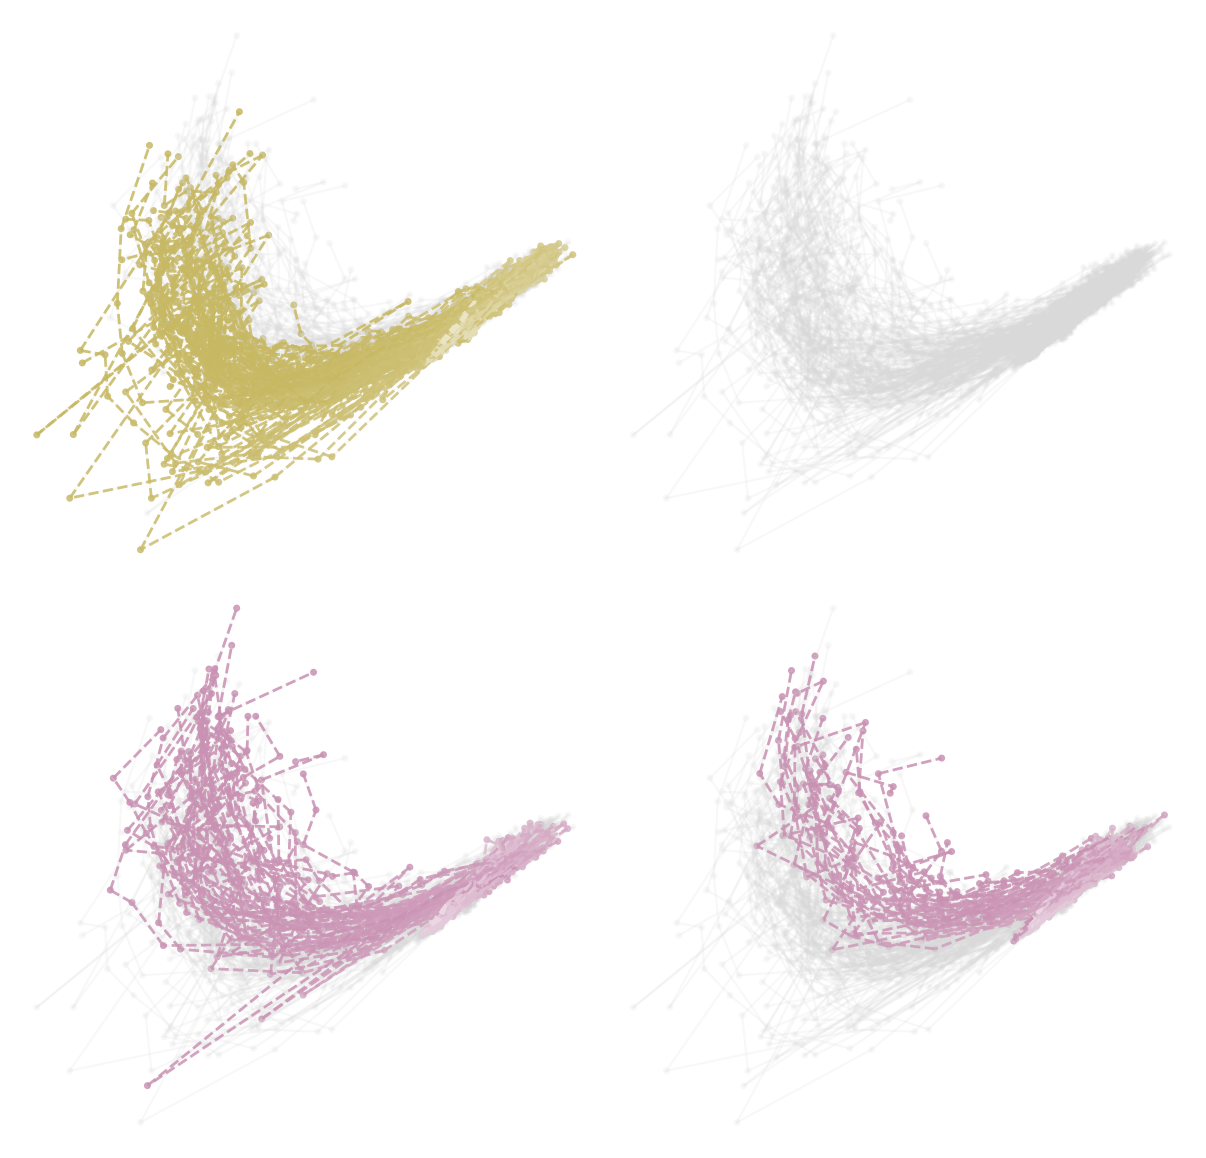

  vit | vascular_function_128 | F1 C = 0.396    F1 CH = 0.495
  vit | vascular_function_128 | C → C | n=36
  vit | vascular_function_128 | C → CH | n=71
  vit | vascular_function_128 | CH → C | n=39
  vit | vascular_function_128 | CH → CH | n=54


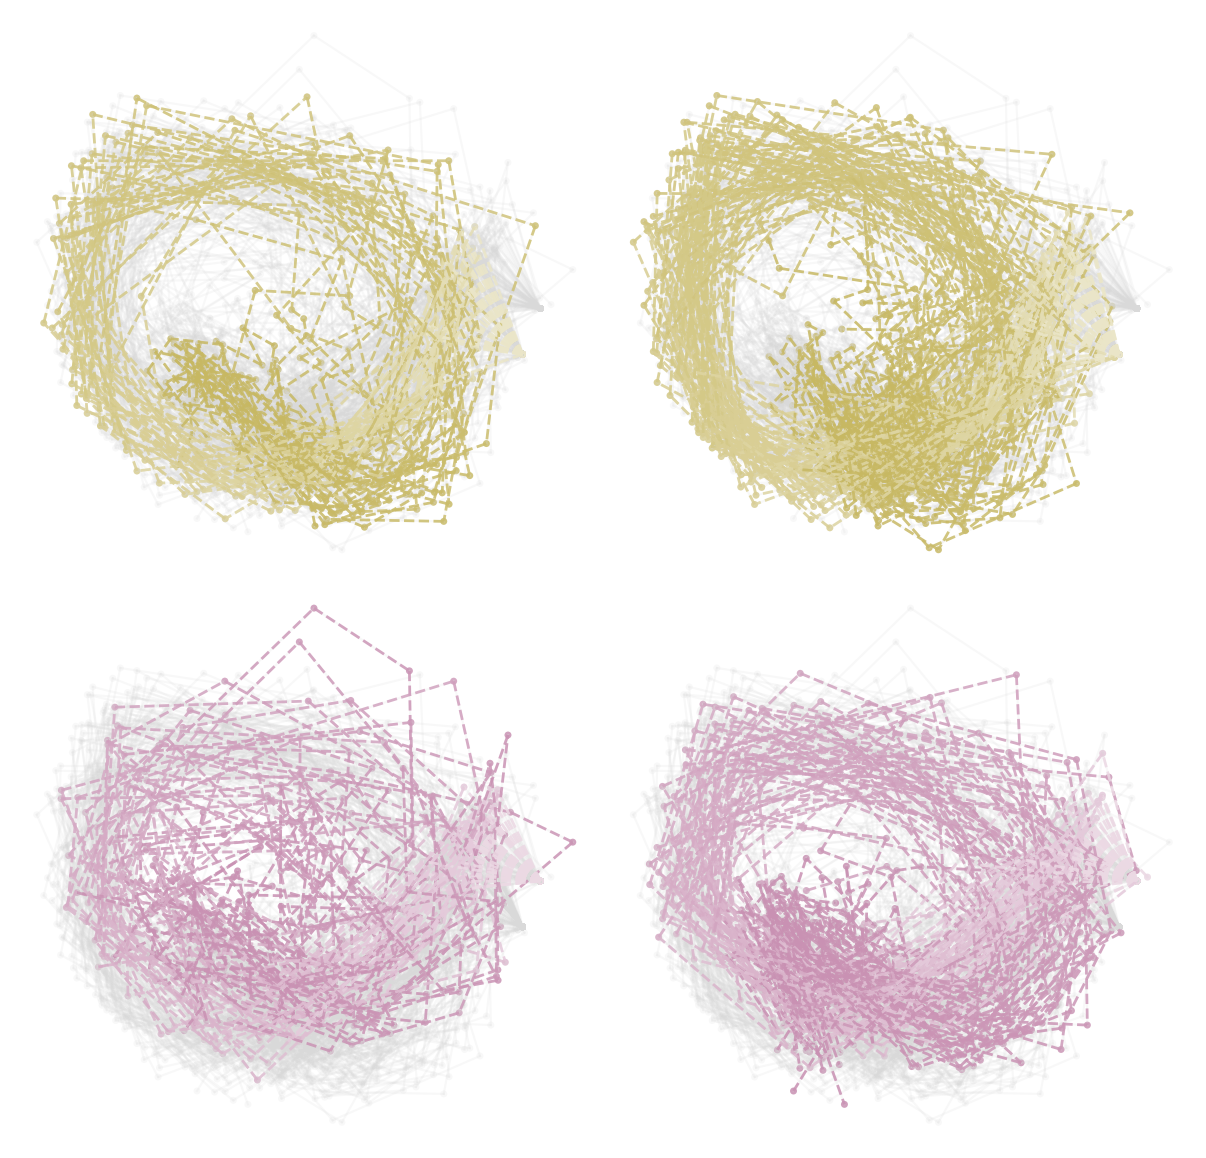

In [ ]:
timepoints, sample_ids = load_encoded_metadata(
    results_dir,
    all_models,
    split="test",
)
nn_embeddings = load_encoded_latents(
    results_dir,
    all_models,
    split="test",
    normalize=True,
)

# Generate PCA embeddings of the latent space
pca_embeddings = {}
for model_name, dataset in nn_embeddings.items():
    pca_embeddings[model_name] = {}
    for dataset_name, embeddings in dataset.items():
        pca = PCA()
        pca_embeddings[model_name][dataset_name] = pca.fit_transform(embeddings)

classification_file = f"results_downstream/classification_results/save/{c['study_dir']}_trajectory_classification_results.json"
classification_results = json.loads(Path(classification_file).read_text(encoding="utf-8"))
incorrect_samples = defaultdict(lambda: defaultdict(list))
for item in classification_results["model_dataset_results"]:
    model_name, dataset_name = item["model_name"], item["dataset_name"]
    incorrect_samples[model_name][dataset_name] = item["incorrect_predictions"]

for model_name, datasets in all_models.items():
    for dataset_name, _model in datasets.items():
        emb = pca_embeddings[model_name][dataset_name]
        ids = sample_ids[model_name][dataset_name]
        tps = timepoints[model_name][dataset_name]
        incorrect = set(incorrect_samples[model_name][dataset_name])

        if STUDY == "gastruloid":
            y_true_by_sid = {s: (0 if str(s).startswith("array1") else 1) for s in set(ids)}
            class_labels = ("Euploid", "Aneuploid")
            fg_top, fg_bottom = "#5C8889", "#D56E2D"
        else:
            y_true_by_sid = {s: (0 if str(s).startswith("C_") else 1) for s in set(ids)}
            class_labels = ("C", "CH")
            fg_top, fg_bottom = "#C7B862", "#C991B3"

        y_pred_by_sid = {s: (yt if s not in incorrect else 1 - yt) for s, yt in y_true_by_sid.items()}
        uids = sorted(y_true_by_sid.keys())
        yt = np.array([y_true_by_sid[s] for s in uids], dtype=int)
        yp = np.array([y_pred_by_sid[s] for s in uids], dtype=int)
        f1p = f1_score(yt, yp, average=None, labels=[0, 1], zero_division=0)
        print(
            f"  {model_name} | {dataset_name} | F1 {class_labels[0]} = {f1p[0]:.3f}    "
            f"F1 {class_labels[1]} = {f1p[1]:.3f}"
        )
        plot_trajectory_confusion_panels(
            emb,
            ids,
            tps,
            incorrect,
            y_true_by_sid,
            class_labels=class_labels,
            fg_top_color=fg_top,
            fg_bottom_color=fg_bottom,
            log_prefix=f"{model_name} | {dataset_name}",
        )
        plt.show()

# Figure 4

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Emergent properties (top → bottom row order):
  1. GROWTH
  2. DIAMETERS
  3. COUNTS
  4. VOLUMES
  5. ACTIVITY
  6. SYMMETRY

Test R² (best row per encoder; panels rows top → bottom):
  property         ae       cae  neuralop       vit
  -------------------------------------------------
  GROWTH        0.448     0.480     0.442     0.499
  DIAMETERS     0.552     0.609     0.484     0.553
  COUNTS        0.463     0.578     0.527     0.448
  VOLUMES       0.549     0.607     0.543     0.511
  ACTIVITY      0.361     0.394     0.432     0.431
  SYMMETRY      0.202     0.259     0.336     0.189


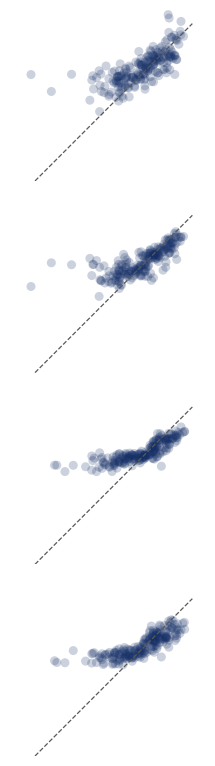

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


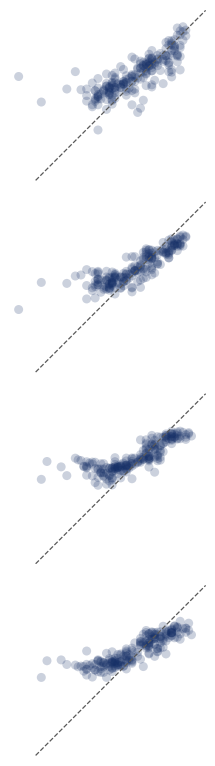

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


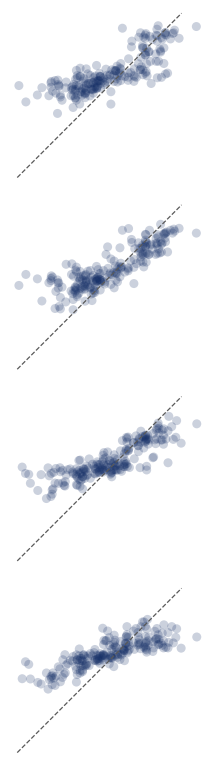

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


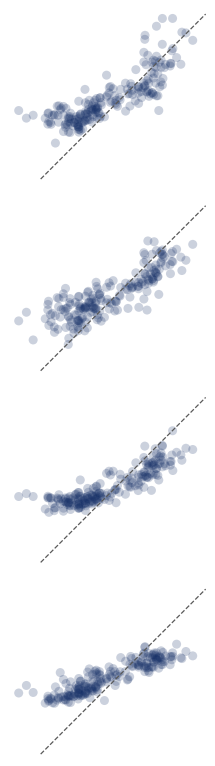

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


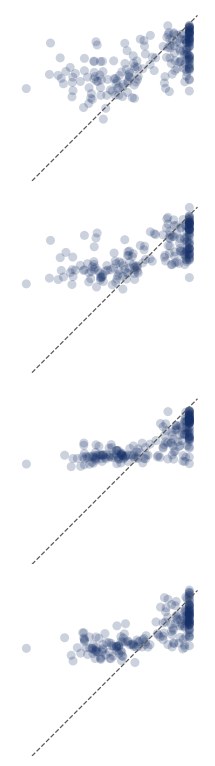

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


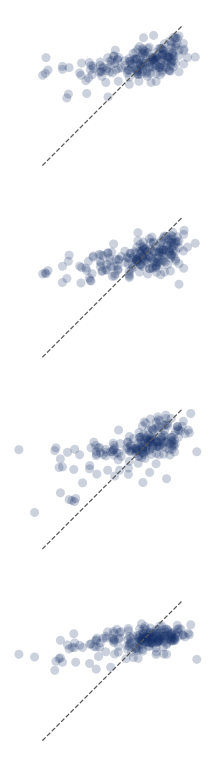

In [ ]:
if STUDY == "gastruloid":
    emergent_properties = ["Mean", "Area","Circ.", "Skew"]
    row_ticks: dict[str, dict[str, list[float] | None]] = {
        "Mean": {"x": [0.0, 150, 300], "y": [0.0, 150, 300]},
        "Area": {"x": [0.0, 4000, 8000], "y": [0.0, 4000, 8000]},
        "XM": {"x": [50, 70, 90], "y": [50, 70, 90]},
        "YM": {"x": [50, 70, 90], "y": [50, 70, 90]},
        "Circ.": {"x": [0.0, 0.5, 1.0], "y": [0.0, 0.5, 1.0]},
    }
else:
    emergent_properties = ["GROWTH", "DIAMETERS","COUNTS","VOLUMES", "ACTIVITY", "SYMMETRY"]
    row_ticks = {
        "VOLUMES": {"x": [200000, 900000, 1600000], "y": [200000,900000, 1600000]},
        "ACTIVITY": {"x": [-0.5, 0.0, 0.5, 1.0], "y": [-0.5, 0.0, 0.5, 1.0]},
        "DIAMETERS": {"x": [5, 15, 25], "y": [5, 15, 25]},
        "GROWTH": {"x": [0.0, 0.75, 1.5], "y": [0.0, 0.75, 1.5]},
        "SYMMETRY": {"x": [0.25, 0.5, 0.75], "y": [0.25, 0.5, 0.75]},
        "COUNTS": {"x": [0, 200, 400], "y": [0, 200, 400]},
    }

results_path = Path("results_downstream") / "classification_results"
results = [load_point_regression_json(results_path, property) for property in emergent_properties]
models = sorted({str(r["model_name"]) for pl in results for r in pl["model_dataset_results"]})

print_emergent_parity_legend(
    emergent_properties, results, models, model_panels="vertical"
)
for property, result in zip(emergent_properties, results):
    plot_emergent_parity_row(
        property,
        result,
        models=models,
        row_ticks=row_ticks,
        tick_labelsize=12,
        model_panels="vertical",
        show_ticks=False,
    )
    plt.show()


In [ ]:
# Figure 4 — best downstream setup per test metric (encoder × regressor_type)
# JSON stores test_r2 / test_mae / test_mse and regressor_type; CV sub-params (e.g. elastic_net alpha)
# are not written to disk by the current export.

results_path_f4 = Path("results_downstream") / "classification_results"
if STUDY == "gastruloid":
    emergent_properties_f4 = ["Mean", "Area", "Circ.", "Skew"]
else:
    emergent_properties_f4 = [
        "GROWTH",
        "DIAMETERS",
        "COUNTS",
        "VOLUMES",
        "ACTIVITY",
        "SYMMETRY",
    ]

_metric_specs_f4 = [
    ("test_r2", "max", "test R²"),
    ("test_mae", "min", "test MAE"),
    ("test_mse", "min", "test MSE"),
]

for prop in emergent_properties_f4:
    payload = load_point_regression_json(results_path_f4, prop)
    rows = payload.get("model_dataset_results") or []
    print(f"\n{'=' * 64}\n{prop}\n{'=' * 64}")
    for key, mode, label in _metric_specs_f4:
        scored = []
        for r in rows:
            if key not in r or r[key] is None:
                continue
            v = float(r[key])
            if not np.isfinite(v):
                continue
            scored.append((v, r))
        if not scored:
            print(f"  {label}: (no finite values)")
            continue
        if mode == "max":
            _v, best = max(scored, key=lambda t: t[0])
        else:
            _v, best = min(scored, key=lambda t: t[0])
        enc = best.get("model_name")
        ds = best.get("dataset_name")
        head = best.get("regressor_type")
        print(
            f"  {label}: {_v:.6g}\n"
            f"    encoder={enc!r}  dataset={ds!r}  regressor_type={head!r}"
        )



GROWTH
  test R²: 0.498541
    encoder='vit'  dataset='vascular_function_128'  regressor_type='mlp'
  test MAE: 0.123586
    encoder='cae'  dataset='vascular_function_128'  regressor_type='random_forest'
  test MSE: 0.0366672
    encoder='vit'  dataset='vascular_function_128'  regressor_type='mlp'

DIAMETERS
  test R²: 0.609164
    encoder='cae'  dataset='vascular_function_128'  regressor_type='mlp'
  test MAE: 1.60146
    encoder='cae'  dataset='vascular_function_128'  regressor_type='mlp'
  test MSE: 4.7371
    encoder='cae'  dataset='vascular_function_128'  regressor_type='mlp'

COUNTS
  test R²: 0.577613
    encoder='cae'  dataset='vascular_function_128'  regressor_type='random_forest'
  test MAE: 42.5138
    encoder='cae'  dataset='vascular_function_128'  regressor_type='random_forest'
  test MSE: 3173.17
    encoder='cae'  dataset='vascular_function_128'  regressor_type='random_forest'

VOLUMES
  test R²: 0.606614
    encoder='cae'  dataset='vascular_function_128'  regressor_typ

### Figure 5

/Users/jacobevarts/BagheriLab/simulation-encoder/.venv/lib/python3.11/site-packages/tltorch/factorized_tensors/factorized_tensors.py:66: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:351.)
  return self.__class__(self.tensor[indices])
/Users/jacobevarts/BagheriLab/simulation-encoder/.venv/lib/python3.11/site-packages/neuralop/layers/spectral_convolution.py:468: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an err

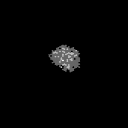

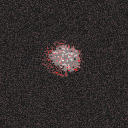

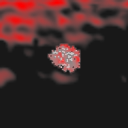

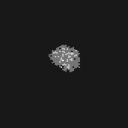

In [ ]:
# panel b — saliency: original + CNN / FNO / ViT overlays
_models_5b = {
    "CNN": all_models["ae"][dataset_name],
    "FNO": all_models["neuralop"][dataset_name],
    "ViT": all_models["vit"][dataset_name],
}
_kw_5b = dict(
    device="cpu",
    saliency_alpha=1.0,
    saliency_white_alpha_floor=0.1,
    saliency_gamma=0.9,
)

if STUDY == "gastruloid":
    fig5b_gastruloid = [
        ("array1_42", 2),
        ("array2_42", 5),        
        ("array1_87", 3),
        ("array2_87", 3),
        ("array1_100", 7)
    ]
    for sid, tp in fig5b_gastruloid:
        sample_idx, split, dataset = resolve_sample_index_in_loaders(
            data_loaders[dataset_name],
            sid,
            tp,
        )
        print(f"Figure 5b — {sid} t={tp} ({split})")
        figs5b = plot_figure5b_saliency_row(
            dataset,
            sample_idx,
            _models_5b,
            **_kw_5b,
        )
        show_figure5b_figures(figs5b)
else:
    fig5b_sample_id = "CH_Sav_8"
    fig5b_timepoint = 14
    sample_idx, _, dataset = resolve_sample_index_in_loaders(
        data_loaders[dataset_name],
        fig5b_sample_id,
        fig5b_timepoint,
    )
    figs5b = plot_figure5b_saliency_row(
        dataset,
        sample_idx,
        _models_5b,
        **_kw_5b,
    )
    show_figure5b_figures(figs5b)



CNN (ae) — top 6 PCs by reconstruction importance
  Rank 1: PC1  var_explained=28.65%  recon_sensitivity=7.9402
  Rank 2: PC2  var_explained=19.59%  recon_sensitivity=5.4684
  Rank 3: PC3  var_explained=17.40%  recon_sensitivity=4.0105
  Rank 4: PC5  var_explained=7.36%  recon_sensitivity=2.8507
  Rank 5: PC4  var_explained=10.64%  recon_sensitivity=1.3096
  Rank 6: PC6  var_explained=5.86%  recon_sensitivity=1.2199


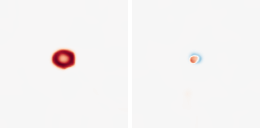

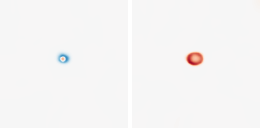

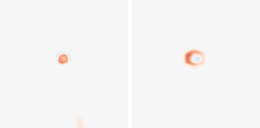

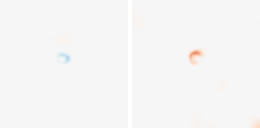

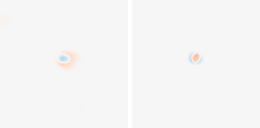

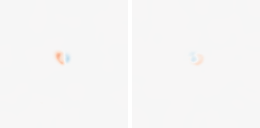


FNO (neuralop) — top 6 PCs by reconstruction importance
  Rank 1: PC1  var_explained=77.51%  recon_sensitivity=11.3887
  Rank 2: PC3  var_explained=7.16%  recon_sensitivity=6.0948
  Rank 3: PC2  var_explained=9.77%  recon_sensitivity=3.0803
  Rank 4: PC4  var_explained=3.64%  recon_sensitivity=2.7060
  Rank 5: PC8  var_explained=0.09%  recon_sensitivity=0.9776
  Rank 6: PC7  var_explained=0.35%  recon_sensitivity=0.7632


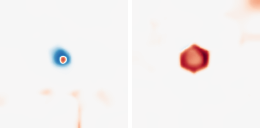

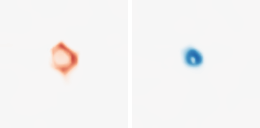

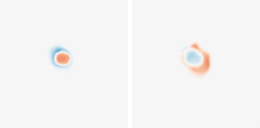

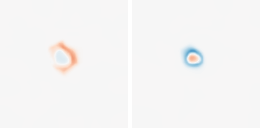

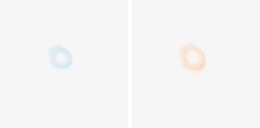

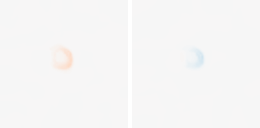


ViT (vit) — top 6 PCs by reconstruction importance
  Rank 1: PC4  var_explained=14.10%  recon_sensitivity=7.7776
  Rank 2: PC2  var_explained=21.80%  recon_sensitivity=6.7428
  Rank 3: PC1  var_explained=30.30%  recon_sensitivity=6.0312
  Rank 4: PC6  var_explained=5.08%  recon_sensitivity=4.8619
  Rank 5: PC5  var_explained=9.39%  recon_sensitivity=4.6033
  Rank 6: PC3  var_explained=16.51%  recon_sensitivity=3.1381


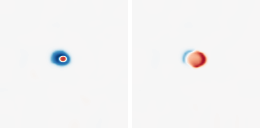

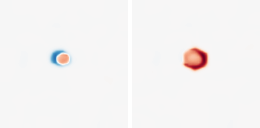

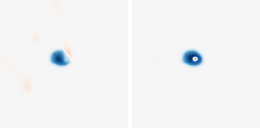

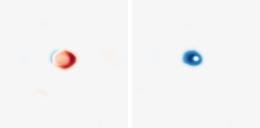

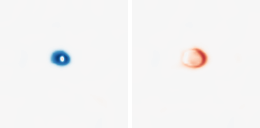

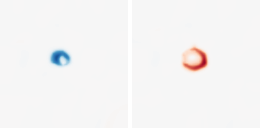

In [ ]:
# panel c — PC perturbation difference images + PSD analysis
FIG5C_MODELS = {
    "CNN": ("ae", dataset_name),
    "FNO": ("neuralop", dataset_name),
    "ViT": ("vit", dataset_name),
}
FIG5C_N_PCS = 6
FIG5C_SIGMA = 3.0

latents_5c = load_encoded_latents(results_dir, all_models, split="test")
psd_results_5c: dict[str, dict] = {}

for label, (model_key, ds_key) in FIG5C_MODELS.items():
    model = all_models[model_key][ds_key]
    Z = latents_5c[model_key][ds_key]

    pca_result = rank_pcs_by_reconstruction_importance(
        model, Z, device="cpu",
    )

    top_pcs = pca_result["importance_order"][:FIG5C_N_PCS]
    print(f"\n{'='*50}")
    print(f"{label} ({model_key}) — top {FIG5C_N_PCS} PCs by reconstruction importance")
    print(f"{'='*50}")
    for rank, k in enumerate(top_pcs, 1):
        var_pct = pca_result["explained_variance_ratio"][k] * 100
        imp = pca_result["reconstruction_importance"][k]
        print(f"  Rank {rank}: PC{k+1}  var_explained={var_pct:.2f}%  recon_sensitivity={imp:.4f}")

    diff_result = generate_pc_perturbation_diffs(
        model, pca_result, top_pcs.tolist(),
        sigma_scale=FIG5C_SIGMA, device="cpu",
    )

    figs5c = plot_figure5c_pc_diffs(
        diff_result,
        save_path_prefix=f"figures/{c['figures_subdir']}/fig5c_{model_key}",
    )
    show_figure5c_figures(figs5c)

    psd_results_5c[label] = compute_pc_perturbation_psd(diff_result)

In [ ]:
# panel c (variant): PC perturbations from a chosen sample_id

FIG5C_SAMPLE_ID = "array1_42"
FIG5C_SAMPLE_TIMEPOINT = 2

FIG5C_MODELS = {
    "CNN": ("ae", dataset_name),
    "FNO": ("neuralop", dataset_name),
    "ViT": ("vit", dataset_name),
}
FIG5C_N_PCS = 6
FIG5C_SIGMA = 3.0

timepoints_5c_s, sample_ids_5c_s = load_encoded_metadata(results_dir, all_models, split="train")
latents_5c_s = load_encoded_latents(results_dir, all_models, split="train")
target_sid = str(FIG5C_SAMPLE_ID).strip()

for label, (model_key, ds_key) in FIG5C_MODELS.items():
    tps = timepoints_5c_s[model_key][ds_key]
    sids = sample_ids_5c_s[model_key][ds_key]
    matches = [
        i
        for i, (s, t) in enumerate(zip(sids, tps))
        if str(s).strip() == target_sid and int(t) == int(FIG5C_SAMPLE_TIMEPOINT)
    ]
    row_idx = matches[0]

    model = all_models[model_key][ds_key]
    Z = latents_5c_s[model_key][ds_key]
    z_sample = Z[row_idx]

    pca_result = rank_pcs_by_reconstruction_importance(model, Z, device="cpu")
    top_pcs = pca_result["importance_order"][:FIG5C_N_PCS]

    print(f"\n{'='*50}")
    print(f"{label} ({model_key})")
    print(f"{'='*50}")
    for rank, k in enumerate(top_pcs, 1):
        var_pct = pca_result["explained_variance_ratio"][k] * 100
        imp = pca_result["reconstruction_importance"][k]
        print(f"  Rank {rank}: PC{k+1}  var_explained={var_pct:.2f}%  recon_sensitivity={imp:.4f}")

    diff_result = generate_pc_perturbation_diffs(
        model,
        pca_result,
        top_pcs.tolist(),
        sigma_scale=FIG5C_SIGMA,
        device="cpu",
        base_latent=z_sample,
    )
    safe_sid = target_sid.replace("/", "_").replace(" ", "_")
    figs5c_s = plot_figure5c_pc_diffs(
        diff_result,
        save_path_prefix=f"figures/{c['figures_subdir']}/fig5c_sample_{safe_sid}_{model_key}",
    )
    show_figure5c_figures(figs5c_s)


IndexError: list index out of range